In [8]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [9]:
df = pd.read_csv("../data/customer_churn_final.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7010, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [10]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7010, 19)
y shape: (7010,)


In [11]:
categorical_features = X.select_dtypes(include="object").columns.tolist()
numerical_features = X.select_dtypes(include="number").columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


/var/folders/m3/2m4l02d545z5f6f72r9z03380000gn/T/ipykernel_24241/4038276858.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include="object").columns.tolist()


In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5608, 19)
X_test: (1402, 19)
y_train: (5608,)
y_test: (1402,)


In [14]:
preprocessor.fit(X_train)

print("Preprocessor fitted successfully.")

Preprocessor fitted successfully.


In [15]:
X_train_processed = preprocessor.transform(X_train)

print("Processed training shape:", X_train_processed.shape)

Processed training shape: (5608, 45)


In [16]:
X_test_processed = preprocessor.transform(X_test)

print("Processed testing shape:", X_test_processed.shape)

Processed testing shape: (1402, 45)


In [17]:
print("Training data shape:", X_train_processed.shape)
print("Testing data shape:", X_test_processed.shape)

print("\nData preprocessing completed successfully.")

Training data shape: (5608, 45)
Testing data shape: (1402, 45)

Data preprocessing completed successfully.


In [18]:
y_train_encoded = y_train.map({"No": 0, "Yes": 1})
y_test_encoded = y_test.map({"No": 0, "Yes": 1})

print("Target encoding completed.")
print(y_train_encoded.value_counts())

Target encoding completed.
Series([], Name: count, dtype: int64)


In [19]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

print("Logistic Regression model created.")

Logistic Regression model created.


In [20]:
print("NaN in X_train_processed:", np.isnan(X_train_processed).sum())
print("NaN in y_train_encoded:", np.isnan(y_train_encoded).sum())

NaN in X_train_processed: 0
NaN in y_train_encoded: 5608


In [21]:
print("y_train values:")
print(y_train.value_counts())

print("\nUnique values:")
print(y_train.unique())

y_train values:
Churn
0    4122
1    1486
Name: count, dtype: int64

Unique values:
[0 1]


In [22]:
print("Encoded target:")
print(y_train_encoded[:10])

Encoded target:
356    NaN
211    NaN
2584   NaN
4622   NaN
2511   NaN
1936   NaN
3997   NaN
4903   NaN
488    NaN
51     NaN
Name: Churn, dtype: float64


In [23]:
y_train_encoded = y_train.astype(int)
y_test_encoded = y_test.astype(int)

print("Unique y_train:", y_train_encoded.unique())
print("Unique y_test:", y_test_encoded.unique())

Unique y_train: [0 1]
Unique y_test: [0 1]


In [24]:
model.fit(X_train_processed, y_train_encoded)

print("Model training completed.")

Model training completed.


In [25]:
y_pred = model.predict(X_test_processed)

print("Predictions generated.")
print(y_pred[:10])

Predictions generated.
[0 0 0 0 0 0 0 0 0 0]


In [26]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test_encoded, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.8081312410841655
Accuracy (%): 80.81312410841655


In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test_encoded, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1031
           1       0.67      0.54      0.60       371

    accuracy                           0.81      1402
   macro avg       0.76      0.72      0.74      1402
weighted avg       0.80      0.81      0.80      1402



In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_encoded, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[932  99]
 [170 201]]


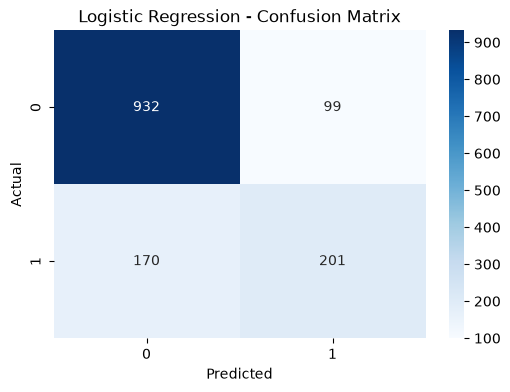

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")

plt.show()

In [30]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test_processed)[:, 1]

roc_auc = roc_auc_score(y_test_encoded, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8472187000818299


In [31]:
import joblib

joblib.dump(model, "../models/logistic_regression.pkl")

print("Logistic Regression model saved successfully.")

Logistic Regression model saved successfully.


In [32]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

print("Random Forest model created.")

Random Forest model created.


In [33]:
rf_model.fit(X_train_processed, y_train_encoded)

print("Random Forest training completed.")

Random Forest training completed.


In [34]:
rf_pred = rf_model.predict(X_test_processed)

print("Random Forest predictions generated.")
print(rf_pred[:10])

Random Forest predictions generated.
[0 0 0 0 0 0 0 0 0 0]


In [35]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test_encoded, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)
print("Accuracy (%):", rf_accuracy * 100)

Random Forest Accuracy: 0.7895863052781741
Accuracy (%): 78.9586305278174


In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_test_encoded, rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1031
           1       0.63      0.49      0.55       371

    accuracy                           0.79      1402
   macro avg       0.73      0.69      0.71      1402
weighted avg       0.78      0.79      0.78      1402



In [37]:
from sklearn.metrics import roc_auc_score

rf_prob = rf_model.predict_proba(X_test_processed)[:, 1]

rf_roc_auc = roc_auc_score(y_test_encoded, rf_prob)

print("Random Forest ROC-AUC:", rf_roc_auc)

Random Forest ROC-AUC: 0.8176292349562485


In [38]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [40]:
import platform
import struct

print("Python:", platform.python_version())
print("Architecture:", platform.machine())
print("Bits:", struct.calcsize("P") * 8)

Python: 3.14.7
Architecture: arm64
Bits: 64


In [41]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

print("Gradient Boosting model created.")

Gradient Boosting model created.


In [42]:
gb_model.fit(X_train_processed, y_train_encoded)

print("Gradient Boosting training completed.")

Gradient Boosting training completed.


In [43]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X_train.select_dtypes(exclude=["object"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing completed.")
print("X_train_processed shape:", X_train_processed.shape)

Preprocessing completed.
X_train_processed shape: (5608, 45)


/var/folders/m3/2m4l02d545z5f6f72r9z03380000gn/T/ipykernel_24241/2428656270.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()


In [44]:
gb_model.fit(X_train_processed, y_train_encoded)

print("Gradient Boosting training completed.")

Gradient Boosting training completed.


In [45]:
gb_pred = gb_model.predict(X_test_processed)

print("Gradient Boosting predictions generated.")
print(gb_pred[:10])

Gradient Boosting predictions generated.
[0 0 0 0 0 0 0 0 0 0]


In [46]:
from sklearn.metrics import accuracy_score

gb_accuracy = accuracy_score(y_test_encoded, gb_pred)

print("Gradient Boosting Accuracy:", gb_accuracy)

Gradient Boosting Accuracy: 0.8052781740370899


In [47]:
from sklearn.metrics import roc_auc_score

gb_prob = gb_model.predict_proba(X_test_processed)[:, 1]

gb_roc_auc = roc_auc_score(y_test_encoded, gb_prob)

print("Gradient Boosting ROC-AUC:", gb_roc_auc)

Gradient Boosting ROC-AUC: 0.8424801503786917


In [49]:
print("Logistic Accuracy:", "log_accuracy" in globals())
print("Random Forest Accuracy:", "rf_accuracy" in globals())
print("Gradient Boosting Accuracy:", "gb_accuracy" in globals())

print("Logistic ROC-AUC:", "log_roc_auc" in globals())
print("Random Forest ROC-AUC:", "rf_roc_auc" in globals())
print("Gradient Boosting ROC-AUC:", "gb_roc_auc" in globals())

Logistic Accuracy: False
Random Forest Accuracy: True
Gradient Boosting Accuracy: True
Logistic ROC-AUC: False
Random Forest ROC-AUC: True
Gradient Boosting ROC-AUC: True


In [50]:
from sklearn.metrics import accuracy_score, roc_auc_score

# Logistic Regression
log_pred = model.predict(X_test_processed)
log_prob = model.predict_proba(X_test_processed)[:, 1]

log_accuracy = accuracy_score(y_test_encoded, log_pred)
log_roc_auc = roc_auc_score(y_test_encoded, log_prob)


# Random Forest
rf_pred = rf_model.predict(X_test_processed)
rf_prob = rf_model.predict_proba(X_test_processed)[:, 1]

rf_accuracy = accuracy_score(y_test_encoded, rf_pred)
rf_roc_auc = roc_auc_score(y_test_encoded, rf_prob)


# Gradient Boosting
gb_pred = gb_model.predict(X_test_processed)
gb_prob = gb_model.predict_proba(X_test_processed)[:, 1]

gb_accuracy = accuracy_score(y_test_encoded, gb_pred)
gb_roc_auc = roc_auc_score(y_test_encoded, gb_prob)


print("Metrics calculated successfully.")
print("Logistic Regression:", log_accuracy, log_roc_auc)
print("Random Forest:", rf_accuracy, rf_roc_auc)
print("Gradient Boosting:", gb_accuracy, gb_roc_auc)

Metrics calculated successfully.
Logistic Regression: 0.8081312410841655 0.8472187000818299
Random Forest: 0.7895863052781741 0.8176292349562485
Gradient Boosting: 0.8052781740370899 0.8424801503786917


In [51]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        log_accuracy,
        rf_accuracy,
        gb_accuracy
    ],
    "ROC-AUC": [
        log_roc_auc,
        rf_roc_auc,
        gb_roc_auc
    ]
})

model_comparison

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.808131,0.847219
1,Random Forest,0.789586,0.817629
2,Gradient Boosting,0.805278,0.842480


In [52]:
best_model_name = model_comparison.loc[
    model_comparison["ROC-AUC"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [53]:
model_comparison.to_csv(
    "../data/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully.")

Model comparison saved successfully.


In [54]:
import os

os.makedirs("../models", exist_ok=True)

print("Models folder ready.")

Models folder ready.


In [55]:
import joblib

joblib.dump(model, "../models/logistic_regression_model.pkl")

print("Logistic Regression model saved.")

Logistic Regression model saved.


In [56]:
joblib.dump(preprocessor, "../models/preprocessor.pkl")

print("Preprocessing pipeline saved.")

Preprocessing pipeline saved.


In [57]:
from sklearn.metrics import classification_report

print("Logistic Regression Classification Report:")
print(classification_report(y_test_encoded, log_pred))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1031
           1       0.67      0.54      0.60       371

    accuracy                           0.81      1402
   macro avg       0.76      0.72      0.74      1402
weighted avg       0.80      0.81      0.80      1402



In [58]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_encoded, log_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[932  99]
 [170 201]]


In [59]:
np.savetxt(
    "../data/confusion_matrix.csv",
    cm,
    delimiter=",",
    fmt="%d"
)

print("Confusion matrix saved successfully.")

Confusion matrix saved successfully.


In [60]:
from sklearn.metrics import classification_report

print("Classification Report - Logistic Regression:")
print(classification_report(y_test_encoded, log_pred))

Classification Report - Logistic Regression:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1031
           1       0.67      0.54      0.60       371

    accuracy                           0.81      1402
   macro avg       0.76      0.72      0.74      1402
weighted avg       0.80      0.81      0.80      1402



In [61]:
report = classification_report(
    y_test_encoded,
    log_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv("../data/classification_report.csv")

print("Classification report saved successfully.")

Classification report saved successfully.


In [62]:
import joblib

joblib.dump(model, "../models/logistic_regression.pkl")

print("Best model saved successfully.")

Best model saved successfully.


In [63]:
joblib.dump(preprocessor, "../models/preprocessor.pkl")

print("Preprocessor saved successfully.")

Preprocessor saved successfully.


In [64]:
import os

print("Model exists:", os.path.exists("../models/logistic_regression.pkl"))
print("Preprocessor exists:", os.path.exists("../models/preprocessor.pkl"))

Model exists: True
Preprocessor exists: True


In [65]:
loaded_model = joblib.load("../models/logistic_regression.pkl")
loaded_preprocessor = joblib.load("../models/preprocessor.pkl")

print("Model and preprocessor loaded successfully.")

Model and preprocessor loaded successfully.


In [66]:
loaded_predictions = loaded_model.predict(X_test_processed)

print("Prediction successful.")
print("First 10 predictions:", loaded_predictions[:10])

Prediction successful.
First 10 predictions: [0 0 0 0 0 0 0 0 0 0]


In [67]:
print("Predictions match:",
      np.array_equal(log_pred, loaded_predictions))

Predictions match: True


In [68]:
gb_pred = gb_model.predict(X_test_processed)

print("Gradient Boosting predictions generated.")
print(gb_pred[:10])

Gradient Boosting predictions generated.
[0 0 0 0 0 0 0 0 0 0]
